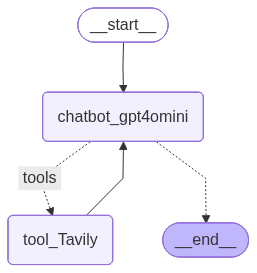

Top 5 largest soil volume in the world

The search did not yield a direct answer to the question regarding the top 5 largest soil volumes in the world. However, I can provide some insights based on general knowledge.

1. **Leptosols**: These are the most widespread major soil group, covering approximately 1,655 million hectares globally. They are found in various regions, including mountainous areas and deserts.

2. **Arenosols**: Covering about 900 million hectares, Arenosols are extensive sandy soils found in regions such as the Kalahari Desert and parts of Australia and the Middle East.

3. **Regosols**: These weakly developed soils cover around 4% of the land surface, with significant areas in polar and arid zones.

4. **Andosols**: Formed from volcanic ash, Andosols are fertile and cover significant areas in regions like Japan and Indonesia.

5. **Vertisols**: Known for their clay-rich composition and expansive presence in places like the African savannas, Vertisols cover large ar

In [3]:
# 必要なモジュールをインポート
import os
from dotenv import load_dotenv
from langchain_openai import ChatOpenAI
from typing import Annotated
from typing_extensions import TypedDict
from langchain_community.tools.tavily_search import TavilySearchResults
from langgraph.graph import StateGraph
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode, tools_condition
from langgraph.checkpoint.memory import MemorySaver

# ===== Stateクラスの定義 =====
class State(TypedDict):
    messages: Annotated[list, add_messages]

# ===== グラフの構築 =====
def build_graph(model_name):
    # ソースコードを記述
    tool = TavilySearchResults(max_results=2)
    tools = [tool]
    graph_builder = StateGraph(State)
    llm = ChatOpenAI(model_name=model_name)
    llm_with_tools = llm.bind_tools(tools)
    def chatbot(state: State):
        return {"messages": [llm_with_tools.invoke(state["messages"])]}
    graph_builder.add_node(f"chatbot_{model_name.replace('-','')}", chatbot)
    graph_builder.add_node("tool_Tavily", ToolNode(tools))
    graph_builder.add_conditional_edges(
        f"chatbot_{model_name.replace('-','')}",
        tools_condition,
        {"tools": "tool_Tavily", "__end__": "__end__"}
    )
    graph_builder.add_edge("tool_Tavily", f"chatbot_{model_name.replace('-','')}")
    graph_builder.set_entry_point(f"chatbot_{model_name.replace('-','')}")
    memory = MemorySaver()
    return graph_builder.compile(checkpointer=memory)

# ===== グラフ実行関数 =====
def stream_graph_updates(graph: StateGraph, user_input: str):
    # ソースコードを記述
    events = graph.stream(
        {"messages": [("user", user_input)]},
        {"configurable": {"thread_id": "1"}},
        stream_mode="values",
    )
    for event in events:
        last_message = event["messages"][-1]
        if getattr(last_message, "type", None) == "tool":
            continue
        print(last_message.content, flush=True)

# ===== メイン実行ロジック =====
# 環境変数の読み込み
load_dotenv("../.env")
os.environ['OPENAI_API_KEY'] = os.environ['API_KEY']

# モデル名
MODEL_NAME = "gpt-4o-mini" 

# グラフの作成
# ソースコードを記述
graph = build_graph(MODEL_NAME)
from IPython.display import Image, display; display(Image(graph.get_graph().draw_mermaid_png()))

# メインループ
# ソースコードを記述
while True:
    user_input = input("質問: ")
    if user_input.strip() == "":
        print("ありがとうございました!")
        break
    stream_graph_updates(graph, user_input)